In [3]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10,6)


In [4]:
df = pd.read_csv("heights.csv")
df.sample(5)

,gender,height
2426,Male,67.285733
4856,Male,66.765467
4547,Male,69.812725
3802,Male,69.007422
9762,Female,69.071271


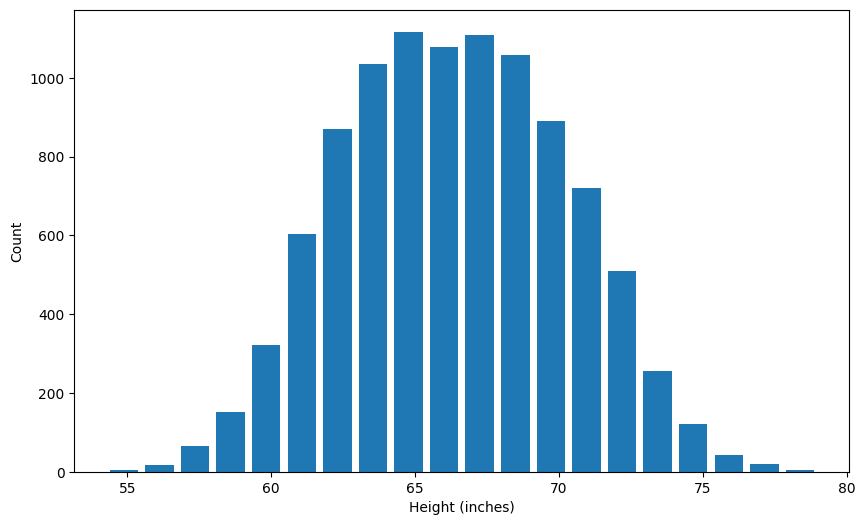

In [5]:
plt.hist(df.height, bins = 20 , rwidth = 0.8)
plt.xlabel("Height (inches)")
plt.ylabel("Count")
plt.show()

In [9]:
df.height.min()

np.float64(54.26313333)

In [10]:
df.height.max()

np.float64(78.99874235)

In [11]:
df.height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: height, dtype: float64

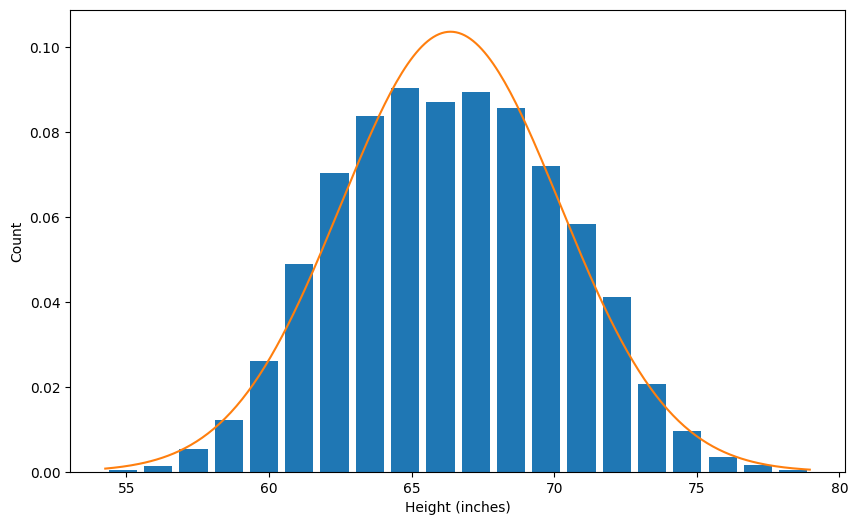

In [8]:
from scipy.stats import norm
import numpy as np

plt.hist(df.height, bins = 20, rwidth = 0.8, density = True)
plt.xlabel("Height (inches)")
plt.ylabel("Count")

rng = np.arange(df.height.min(), df.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.height.mean(), df.height.std()))

In [12]:
df.height.mean()

np.float64(66.367559754866)

In [13]:
df.height.std()

np.float64(3.847528120795573)

In [14]:
upper_limit = df.height.mean() + 3*df.height.std()
upper_limit

np.float64(77.91014411725271)

In [15]:
lower_limit = df.height.mean() - 3*df.height.std()
lower_limit

np.float64(54.824975392479274)

In [16]:
df[(df.height > upper_limit) | (df.height<lower_limit)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [19]:
df_no_outlier_std_dev = df[(df.height < upper_limit) & (df.height > lower_limit)]
df_no_outlier_std_dev

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796
...,...,...
9995,Female,66.172652
9996,Female,67.067155
9997,Female,63.867992
9998,Female,69.034243


In [20]:
df.shape[0] - df_no_outlier_std_dev.shape[0]

7

In [22]:
df['zscore'] = (df.height - df.height.mean())/df.height.std()
df.head(5)

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [23]:
df[df['zscore'] > 3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [24]:
df[df['zscore'] < -3]

,gender,height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [25]:
df[(df.zscore < -3) | (df.zscore > 3)]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [26]:
df_no_outliers = df[(df.zscore > -3) & (df.zscore < 3)]
df_no_outliers.head()

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [27]:
df.shape[0] - df_no_outliers.shape[0]

7